In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
import gurobipy as gp
from gurobipy import GRB

### RDC 생성

block 별로 생성

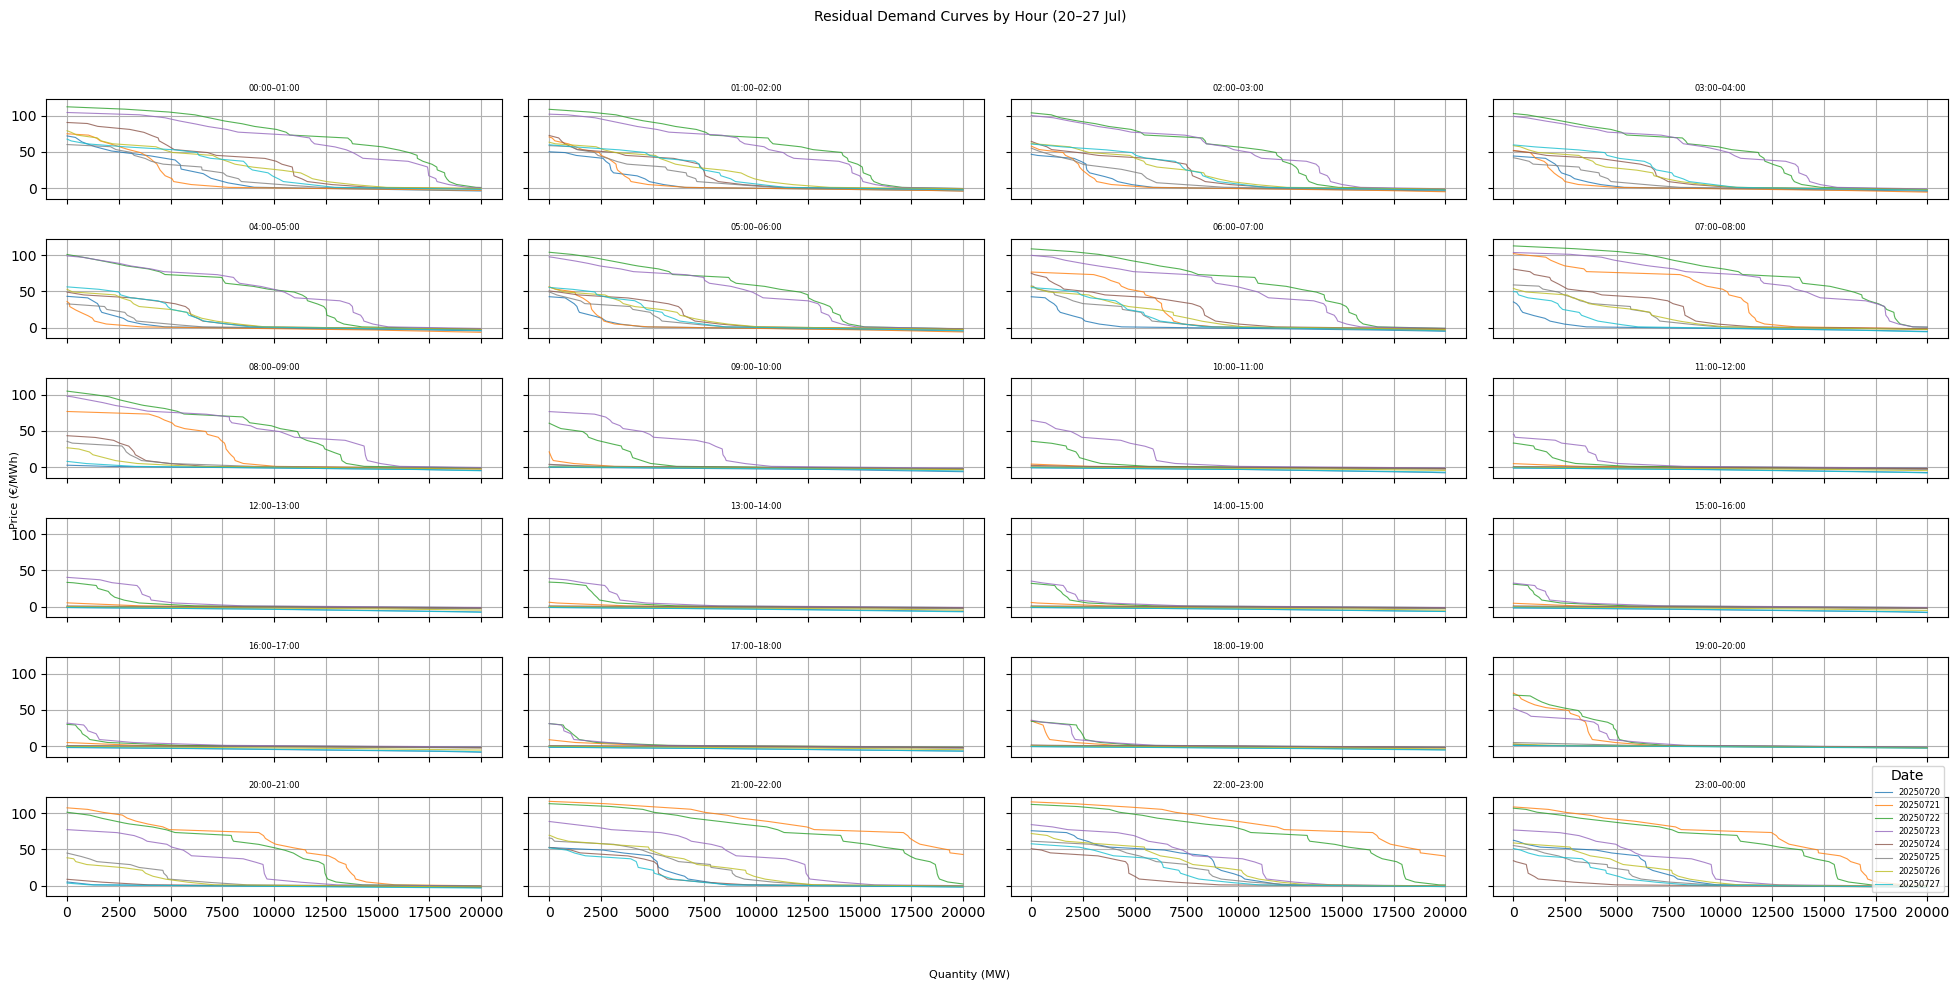

In [4]:
# --- A) RDC 계산 함수 (생략) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- B) 공통 설정 ---
days          = range(20,28)                 # 7/20~7/27
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

B             = 500                   # stepwise 블록 개수

# stepwise 파라미터 저장용
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- D) 각 Period(1~24) 에 대해 ---
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        # 이미 Price/Amount가 float 라고 가정
        sub    = df[df['Time Period']==period]
        sup    = sub[sub['GC']=='V']
        dem    = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 집계 & 누적
        # 집계 & 누적
        s_agg = sup.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        # 가격 낮을수록 누적이 커져야 하니 역순 누적
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간
        s_f = interp1d(
            s_agg['Price'], s_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(0, s_agg['Cumul'].iat[-1])
        )
        d_f = interp1d(
            d_agg['Price'], d_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(d_agg['Cumul'].iat[0], 0)
        )

        pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv  = s_f(pg)
        dv  = d_f(pg)
        #Original Clearing Price 계산
        def resid0(p): 
            return d_f(p) - s_f(p)   # q=0
        sol0 = root_scalar(resid0,
                           bracket=[pg[0], pg[-1]],
                           method='bisect')
        orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan


        # wf_offer_grid = np.arange(
        #     0,
        #     s_agg['Cumul'].max() * 1.2,
        #     100
        # )

        wf_offer_grid = np.arange(
            0,
            20000,
            10
        )
        
        # Residual Demand
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # ——— stepwise 근사 파라미터 계산 —————————
        q_breaks = np.linspace(0, qv.max(), B+1)
        delta_qs = q_breaks[1:] - q_breaks[:-1]
        for b in range(B):
            mid = 0.5*(q_breaks[b] + q_breaks[b+1])
            # date_str, period, block b 를 키로 사용
            qini   [(date_str, period, b)] = float(q_breaks[b])
            qmax   [(date_str, period, b)] = float(delta_qs[b])
            lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
        # ————————————————————————————————

        # RDC Curve만 플롯
        # ax.plot(qv, pv, 'o-', color=color, label=date_str)
        ax.plot(
            qv, pv,
            '-',                # 실선만
            color=color,
            label=date_str,
            linewidth=0.8,
            alpha=0.8
        )

    # subplot 제목 (예: “00:00–01:00”)
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# --- E) 공통 레이블 & 레이아웃 ---
fig.supxlabel('Quantity (MW)', fontsize=8)
fig.supylabel('Price (€/MWh)', fontsize=8)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# 범례는 맨 마지막 축에만 표시하도록
axes[-1].legend(title='Date', fontsize=6, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


offer 별로 생성

C:\Users\symply_jina\AppData\Local\Temp\ipykernel_10696\4154531031.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(title='Date', fontsize=8, loc='lower right')


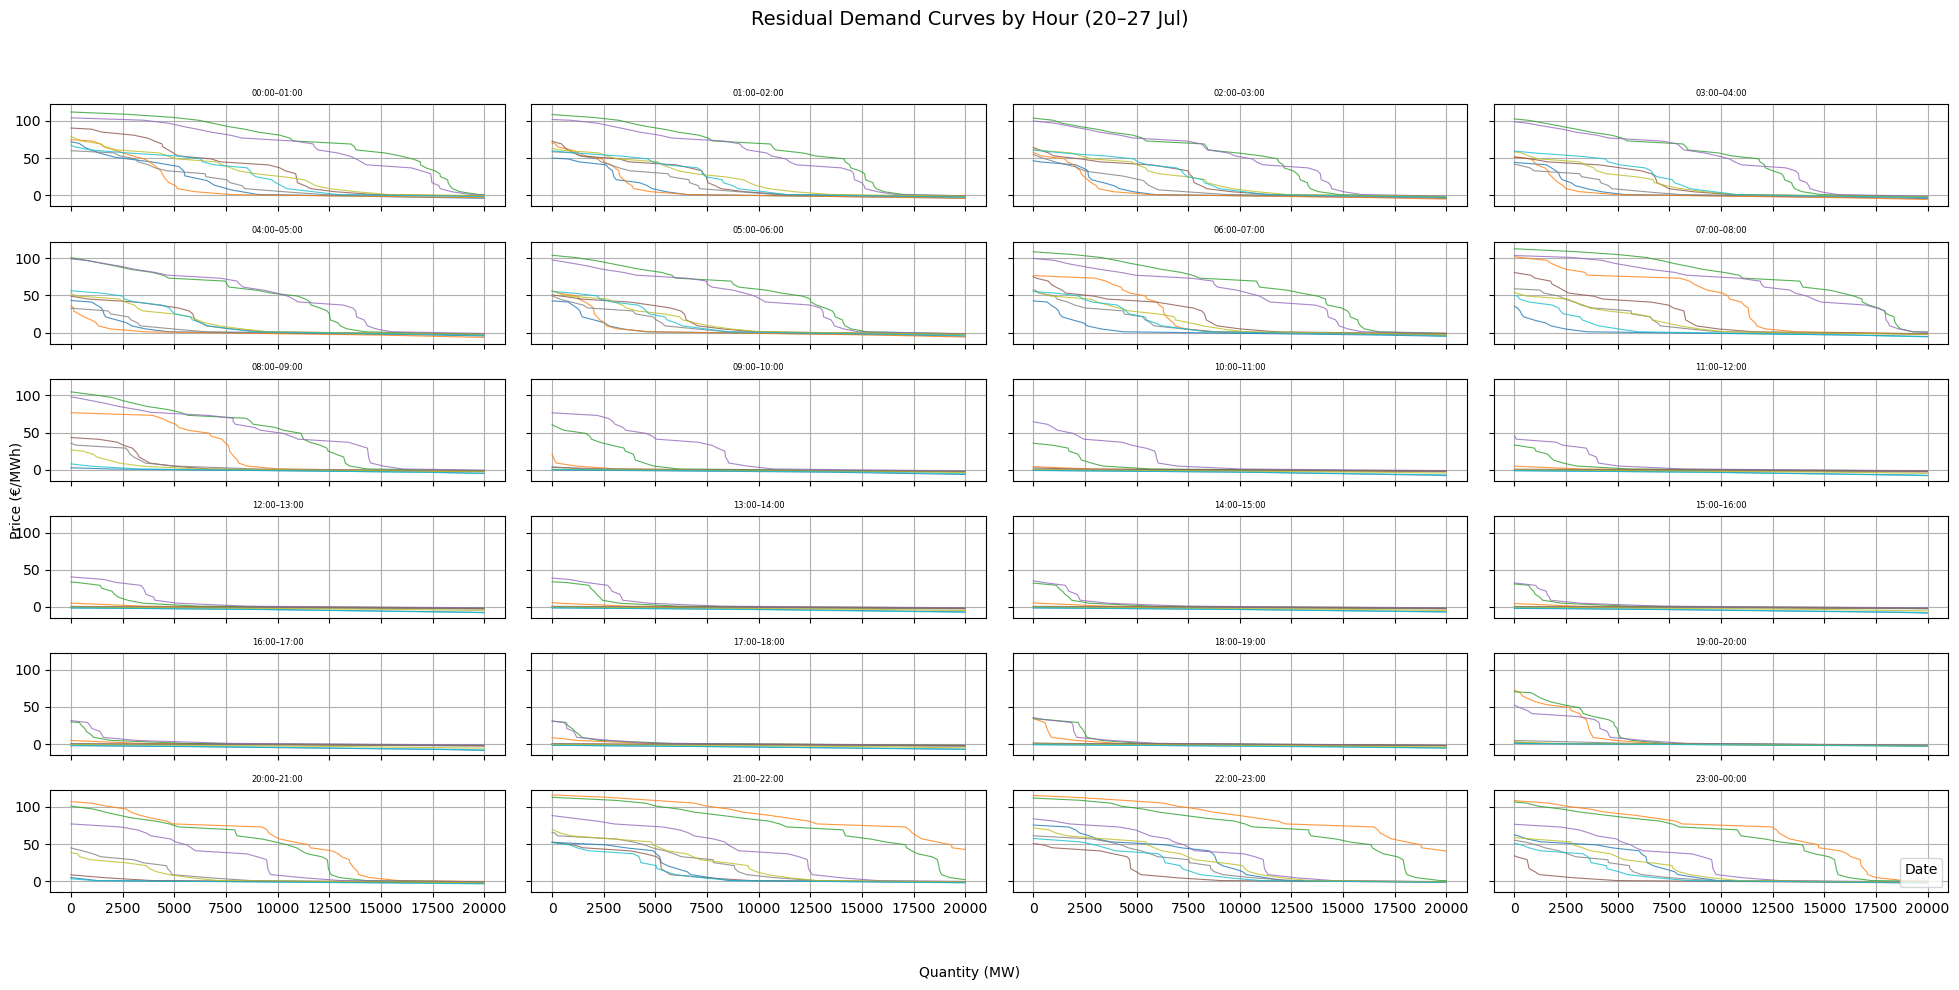

In [69]:
# ────────────────────────────────────────────────────
# A) 잔여수요 계산 함수 (선형보간)
# ────────────────────────────────────────────────────
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i],       resid[i+1]
            if r1 != r0:
                # 선형 보간으로 교차점 계산
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc

# ────────────────────────────────────────────────────
# B) 공통 설정
# ────────────────────────────────────────────────────
days   = range(20,28)  # 7/20~7/27
colors = plt.cm.tab10(np.linspace(0,1,len(days)))

# 결과 저장용 dict
qini            = {}   # (date, period, block) → block 시작 Q
qmax            = {}   # (date, period, block) → block 크기 ΔQ
lambda_da_block = {}   # (date, period, block) → DA 가격
orig_cp         = {}   # (date, period) → cleared price @ q=0

# ────────────────────────────────────────────────────
# C) 4×6 서브플롯 생성 (figsize=20×10)
# ────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# ────────────────────────────────────────────────────
# D) 각 Period(1~24)에 대해
# ────────────────────────────────────────────────────
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        sub = df[df['Time Period']==period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 1) 공급/수요 집계 & 누적
        s_agg = (sup.groupby('Price')['Amount']
                    .sum().reset_index()
                    .sort_values('Price'))
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = (dem.groupby('Price')['Amount']
                    .sum().reset_index()
                    .sort_values('Price'))
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 2) 계단형 보간 함수
        s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(d_agg['Cumul'].iat[0], 0))

        # 3) price grid 위에서 누적량 계산
        pg = np.linspace(s_agg['Price'].min(),
                         d_agg['Price'].max(), 500)
        sv = s_f(pg)
        dv = d_f(pg)

        # 4) q=0 일 때의 original clearing price
        def resid0(p): return d_f(p) - s_f(p)
        sol0 = root_scalar(resid0,
                           bracket=[pg[0], pg[-1]],
                           method='bisect')
        orig_cp[(date_str,period)] = sol0.root if sol0.converged else np.nan

        # 5) 100 MW 스텝별 WF‐offer 그리드 정의
        # wf_offer_grid = np.arange(0, s_agg['Cumul'].max() * 1.2, 100)
        wf_offer_grid = np.arange(0, 20000, 10) 

        # 6) Residual Demand Curve 계산
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # 7) “블록”을 WF‐offer 스텝 그대로 정의
        q_breaks = wf_offer_grid
        delta_qs = np.diff(wf_offer_grid)   # 모두 100
        for b, (q0, dq) in enumerate(zip(q_breaks[:-1], delta_qs)):
            mid = q0 + dq/2
            qini   [(date_str,period,b)] = float(q0)
            qmax   [(date_str,period,b)] = float(dq)
            lambda_da_block[(date_str,period,b)] = float(
                np.interp(mid, qv, pv)
            )

        # 8) RDC 플롯
        ax.plot(qv, pv,
                '-', color=color,
                linewidth=0.8, alpha=0.8)

    # subplot 제목 설정
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# ────────────────────────────────────────────────────
# E) 공통 레이아웃
# ────────────────────────────────────────────────────
fig.supxlabel('Quantity (MW)', fontsize=10)
fig.supylabel('Price (€/MWh)', fontsize=10)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=14)
axes[-1].legend(title='Date', fontsize=8, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


Adaptive

C:\Users\symply_jina\AppData\Local\Temp\ipykernel_10696\42558502.py:111: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_10696\42558502.py:111: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_10696\42558502.py:111: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_10696\42558502.py:111: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_10696\42558502.py:111: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff(pv) / np.diff(qv))
C:\Users\symply_jina\AppData\Local\Temp\ipykernel_10696\42558502.py:111: RuntimeWarning: invalid value encountered in divide
  slopes = np.abs(np.diff

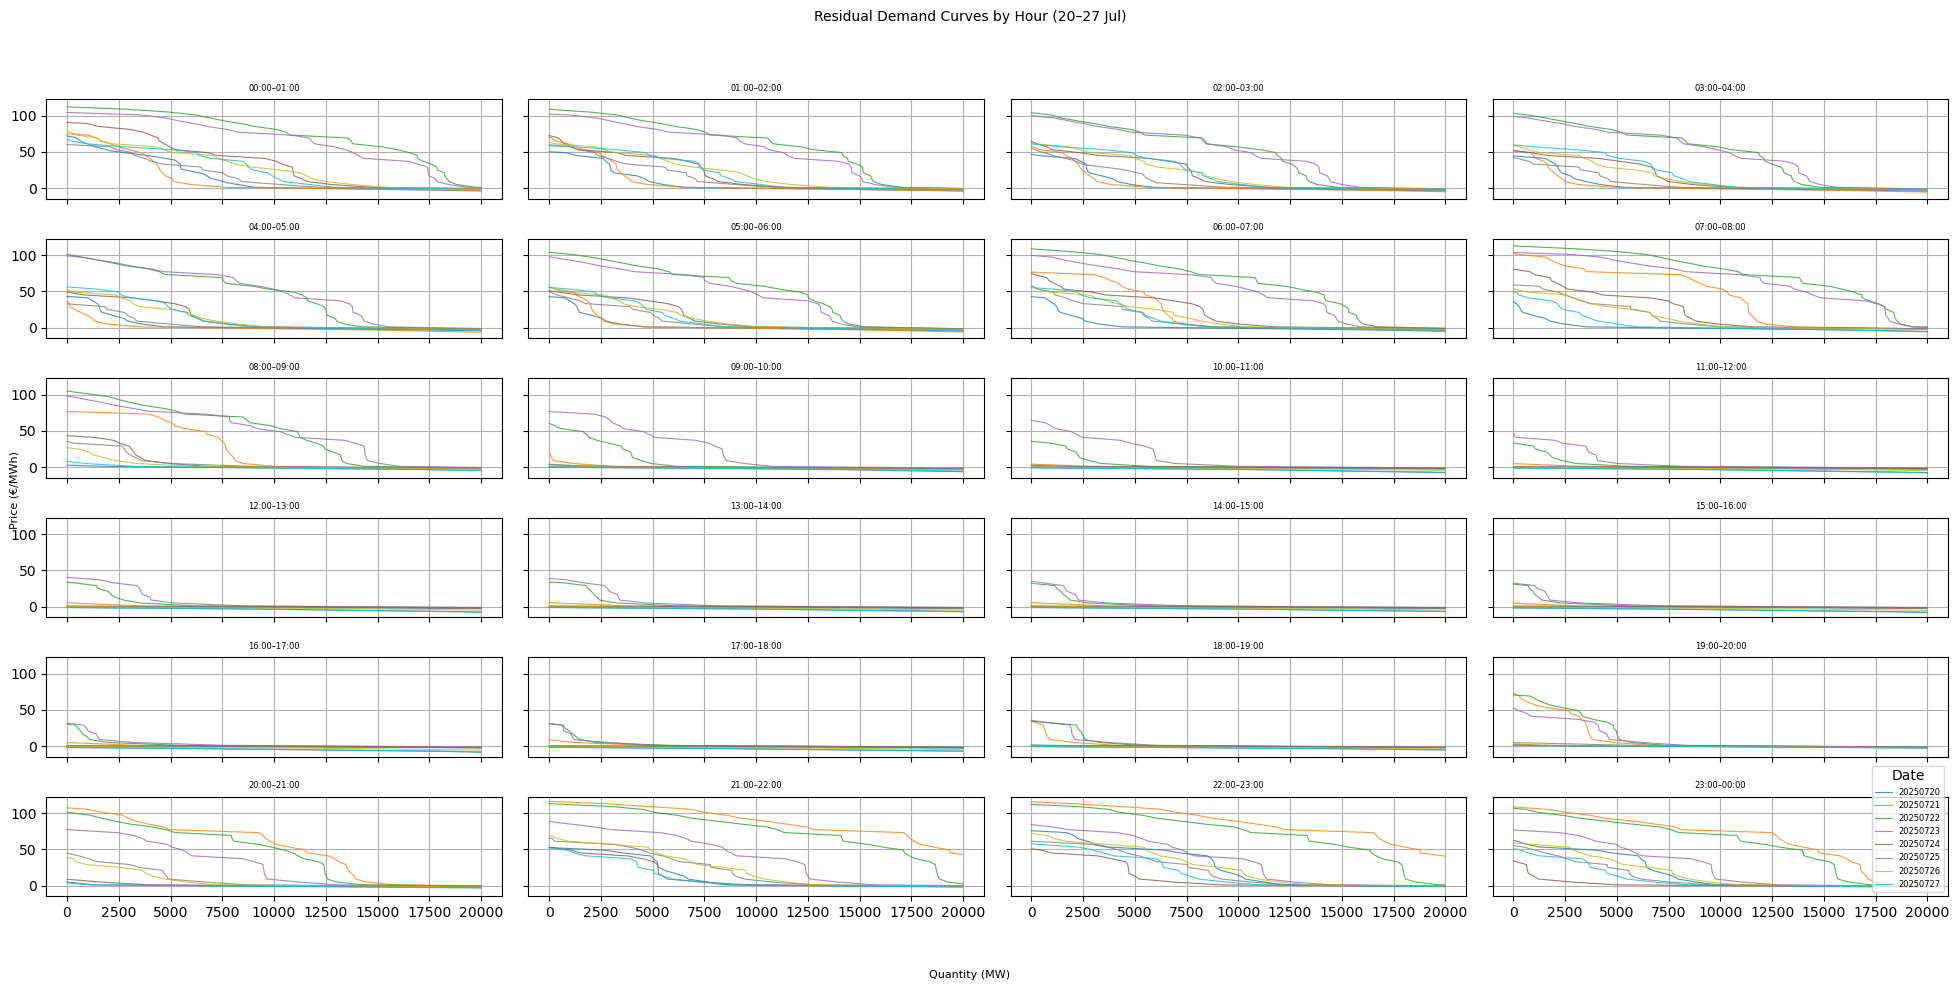

In [90]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d
# from scipy.optimize import root_scalar

# --- A) RDC 계산 함수 (생략) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- B) 공통 설정 ---
days          = range(20,28)                 # 7/20~7/27
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

B             = 100                   # stepwise 블록 개수 (※ adaptive에서는 사용 안 함)

# stepwise 파라미터 저장용
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- D) 각 Period(1~24) 에 대해 ---
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        # 이미 Price/Amount가 float 라고 가정
        sub    = df[df['Time Period']==period]
        sup    = sub[sub['GC']=='V']
        dem    = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 집계 & 누적
        s_agg = sup.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        # 가격 낮을수록 누적이 커져야 하니 역순 누적
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간
        s_f = interp1d(
            s_agg['Price'], s_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(0, s_agg['Cumul'].iat[-1])
        )
        d_f = interp1d(
            d_agg['Price'], d_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(d_agg['Cumul'].iat[0], 0)
        )

        pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv  = s_f(pg)
        dv  = d_f(pg)

        # Original Clearing Price 계산
        def resid0(p): 
            return d_f(p) - s_f(p)   # q=0
        sol0 = root_scalar(resid0,
                           bracket=[pg[0], pg[-1]],
                           method='bisect')
        orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan

        # wf_offer_grid
        wf_offer_grid = np.arange(0, 20000, 1)
        
        # Residual Demand
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # ——— [NEW] Adaptive stepwise 근사 파라미터 계산 —————————
        # 하이퍼파라미터(원하면 조정)
        STEP_SMALL, STEP_MEDIUM, STEP_LARGE = 10, 50, 200   # MW 단위
        PCT_STEEP, PCT_FLAT = 70, 30                        # |dP/dQ| 분위수 기준
        MAX_BLOCKS = 5000                                   # 안전장치

        # 국소 기울기 |dP/dQ|
        slopes = np.abs(np.diff(pv) / np.diff(qv))
        slopes = np.nan_to_num(slopes, nan=0.0, posinf=0.0, neginf=0.0)

        # 분위수 기준 (데이터가 적을 때의 fallback 포함)
        if (slopes > 0).sum() >= 3:
            alpha, beta = np.percentile(slopes[slopes > 0], [PCT_STEEP, PCT_FLAT])
        elif len(slopes):
            alpha, beta = slopes.max(), np.median(slopes)
        else:
            alpha, beta = 0.0, 0.0  # 모든 구간 평탄한 경우

        # q축을 기울기에 따라 가변 스텝으로 분할
        q_breaks = [0.0]
        guard = 0
        while q_breaks[-1] < qv.max() and guard < MAX_BLOCKS:
            k = np.searchsorted(qv, q_breaks[-1], side="right") - 1
            k = np.clip(k, 0, len(slopes)-1)
            s = slopes[k]
            step = STEP_SMALL if s > alpha else STEP_MEDIUM if s > beta else STEP_LARGE
            q_next = min(q_breaks[-1] + step, float(qv.max()))
            if q_next - q_breaks[-1] <= 1e-9:
                break
            q_breaks.append(q_next)
            guard += 1

        q_breaks = np.array(q_breaks)
        delta_qs = np.diff(q_breaks)

        # 블록 파라미터 저장(기존 dict 구조 그대로)
        for b in range(len(delta_qs)):
            mid = 0.5*(q_breaks[b] + q_breaks[b+1])
            qini[(date_str, period, b)] = float(q_breaks[b])
            qmax[(date_str, period, b)] = float(delta_qs[b])
            lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
        # ————————————————————————————————

        # RDC Curve만 플롯
        ax.plot(
            qv, pv,
            '-',                # 실선만
            color=color,
            label=date_str,
            linewidth=0.8,
            alpha=0.8
        )

    # subplot 제목 (예: “00:00–01:00”)
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# --- E) 공통 레이블 & 레이아웃 ---
fig.supxlabel('Quantity (MW)', fontsize=8)
fig.supylabel('Price (€/MWh)', fontsize=8)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# 범례는 맨 마지막 축에만 표시하도록
axes[-1].legend(title='Date', fontsize=6, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


Piecewise Linearisation

C:\Users\symply_jina\AppData\Local\Temp\ipykernel_10696\2360823092.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(title='Date', fontsize=6, loc='lower right')


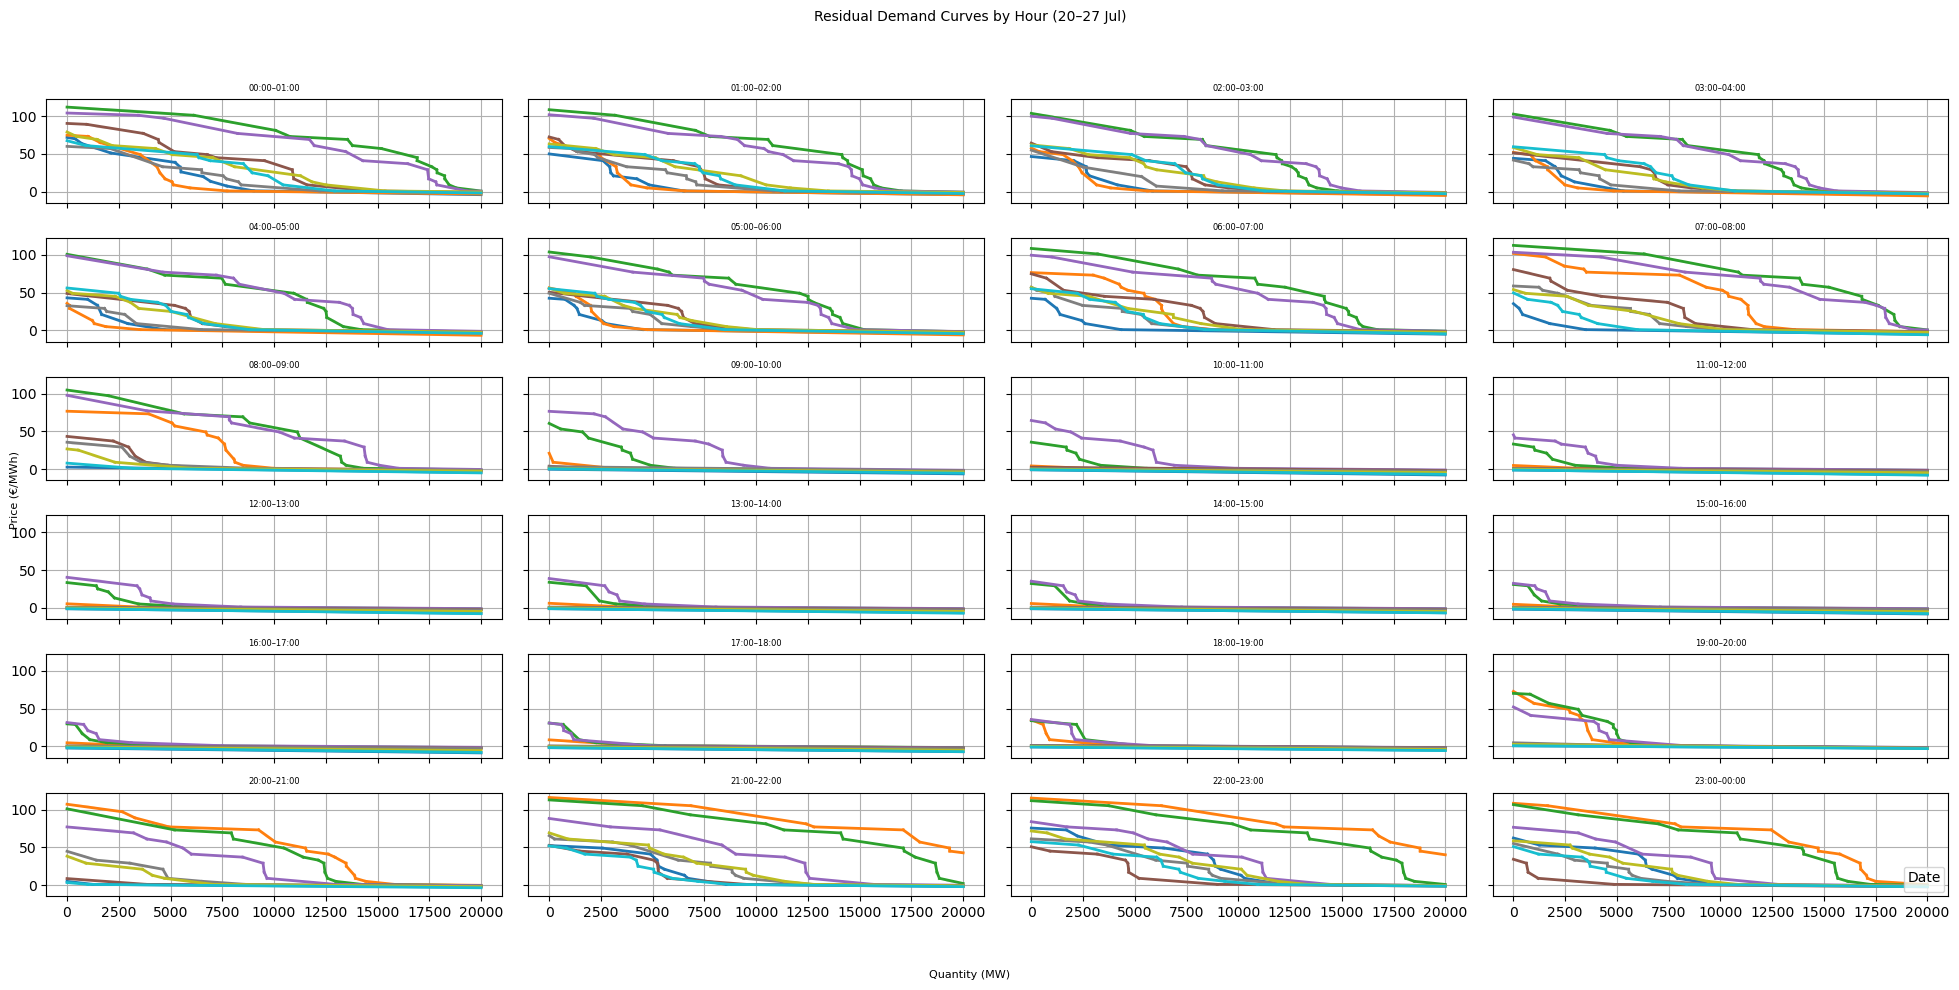

In [96]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d
# from scipy.optimize import root_scalar

# ====== [NEW] RDP 기반 PWL 보조함수 ======
def _perp_dist(x0, y0, x1, y1, xi, yi):
    # 선분 (x0,y0)-(x1,y1) 에 대한 점 (xi,yi) 의 수선거리
    if x0 == x1 and y0 == y1:
        return abs(yi - y0)
    num = abs((y1-y0)*xi - (x1-x0)*yi + x1*y0 - y1*x0)
    den = ((y1-y0)**2 + (x1-x0)**2) ** 0.5
    return num / den

def rdp_breakpoints(q, p, eps):
    # q, p: 1D numpy arrays (단조 증가 가정)
    idxs = [0, len(q)-1]
    stack = [(0, len(q)-1)]
    while stack:
        i0, i1 = stack.pop()
        q0, p0 = q[i0], p[i0]
        q1, p1 = q[i1], p[i1]
        imax, dmax = -1, -1.0
        if i1 - i0 >= 2:
            for i in range(i0+1, i1):
                d = _perp_dist(q0, p0, q1, p1, q[i], p[i])
                if d > dmax:
                    dmax, imax = d, i
            if dmax > eps:
                idxs.append(imax)
                stack.append((i0, imax))
                stack.append((imax, i1))
    idxs = sorted(set(idxs))
    return np.array(idxs, dtype=int)

# --- A) RDC 계산 함수 ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- B) 공통 설정 ---
days          = range(20,28)                 # 7/20~7/27
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
B             = 100  # (이제 사용 안 함)

# stepwise(이전) 대신, 필요하면 세그먼트 저장용
pwl_segments = {}     # key=(date_str, period) -> list of (q0,q1,m,c)

qini, qmax, lambda_da_block, orig_cp = {}, {}, {}, {}

# [NEW] PWL 튜닝
EPSILON = 2.0   # €/MWh 허용 오차(작을수록 세그먼트 많아짐)
MAX_SEGS = 40   # 세그먼트 상한 (너무 많으면 보기 힘드니까)

# --- C) 4×6 서브플롯 생성 (figsize 20×10) ---
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- D) 각 Period(1~24) 에 대해 ---
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        sub    = df[df['Time Period']==period]
        sup    = sub[sub['GC']=='V']
        dem    = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 집계 & 누적
        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간
        s_f = interp1d(
            s_agg['Price'], s_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(0, s_agg['Cumul'].iat[-1])
        )
        d_f = interp1d(
            d_agg['Price'], d_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(d_agg['Cumul'].iat[0], 0)
        )

        pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv  = s_f(pg)
        dv  = d_f(pg)

        # Original Clearing Price
        def resid0(p): 
            return d_f(p) - s_f(p)
        sol0 = root_scalar(resid0, bracket=[pg[0], pg[-1]], method='bisect')
        orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan

        # RDC points
        wf_offer_grid = np.arange(0, 20000, 1)
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = map(np.array, zip(*rdc_pts))
        if len(qv) < 2:
            continue

        # --- [NEW] PWL 근사 계산 ---------------------------------
        idxs = rdp_breakpoints(qv, pv, EPSILON)

        # 세그먼트가 너무 많으면 균등 다운샘플
        if MAX_SEGS and len(idxs)-1 > MAX_SEGS:
            keep = np.linspace(0, len(idxs)-1, MAX_SEGS+1).round().astype(int)
            idxs = idxs[keep]

        segs = []
        for k in range(len(idxs)-1):
            i0, i1 = idxs[k], idxs[k+1]
            q0, q1 = float(qv[i0]), float(qv[i1])
            p0, p1 = float(pv[i0]), float(pv[i1])
            if q1 == q0:
                m = np.inf; c = np.nan
            else:
                m = (p1 - p0) / (q1 - q0)
                c = p0 - m * q0
            segs.append((q0, q1, m, c, p0, p1))
        pwl_segments[(date_str, period)] = segs
        # ---------------------------------------------------------

        # 원래 RDC(얇게)
        ax.plot(qv, pv, '-', color=color, alpha=0.25, linewidth=0.7)

        # PWL 근사(두껍게)
        for (q0, q1, m, c, p0, p1) in segs:
            qq = np.array([q0, q1])
            pp = (m * qq + c) if np.isfinite(m) else np.array([p0, p1])
            ax.plot(qq, pp, color=color, linewidth=2.0)

    # subplot 제목
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# --- E) 공통 레이블 & 레이아웃 ---
fig.supxlabel('Quantity (MW)', fontsize=8)
fig.supylabel('Price (€/MWh)', fontsize=8)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)
axes[-1].legend(title='Date', fontsize=6, loc='lower right')
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


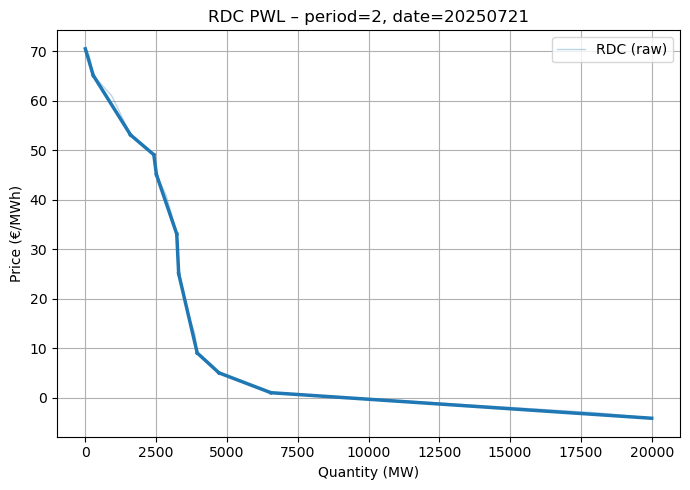

In [ ]:
# === RDP(PWL) 유틸 ===
def _perp_dist(x0, y0, x1, y1, xi, yi):
    if x0 == x1 and y0 == y1:
        return abs(yi - y0)
    num = abs((y1-y0)*xi - (x1-x0)*yi + x1*y0 - y1*x0)
    den = ((y1-y0)**2 + (x1-x0)**2) ** 0.5
    return num / den

def rdp_breakpoints(q, p, eps):
    idxs = [0, len(q)-1]
    stack = [(0, len(q)-1)]
    while stack:
        i0, i1 = stack.pop()
        if i1 - i0 < 2: 
            continue
        q0, p0 = q[i0], p[i0]
        q1, p1 = q[i1], p[i1]
        imax, dmax = -1, -1.0
        for i in range(i0+1, i1):
            d = _perp_dist(q0, p0, q1, p1, q[i], p[i])
            if d > dmax:
                dmax, imax = d, i
        if dmax > eps:
            idxs.append(imax)
            stack.append((i0, imax))
            stack.append((imax, i1))
    return np.array(sorted(set(idxs)), dtype=int)

# === RDC 계산 ===
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1 != r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc

# === 단일 period/date 그리기 ===
def plot_rdc_pwl_for(date_str="20250720", period=2, EPSILON=2.0, MAX_SEGS=40):
    fn = f"filteredcurve_{date_str}.csv"
    df = pd.read_csv(fn, encoding='utf-8-sig')

    sub = df[df['Time Period'] == period]
    sup = sub[sub['GC'] == 'V']
    dem = sub[sub['GC'] == 'C']
    if sup.empty or dem.empty:
        raise ValueError("해당 period에 공급/수요 데이터가 없습니다.")

    s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    s_agg['Cumul'] = s_agg['Amount'].cumsum()

    d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

    s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
                   kind='previous', bounds_error=False,
                   fill_value=(0, s_agg['Cumul'].iat[-1]))
    d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
                   kind='previous', bounds_error=False,
                   fill_value=(d_agg['Cumul'].iat[0], 0))

    pg = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
    sv = s_f(pg); dv = d_f(pg)

    # RDC points
    wf_offer_grid = np.arange(0, 20000, 1)
    rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
    if not rdc_pts: 
        raise ValueError("RDC가 계산되지 않았습니다.")
    qv, pv = map(np.array, zip(*rdc_pts))
    if len(qv) < 2:
        raise ValueError("RDC 점이 부족합니다.")

    # PWL 근사
    idxs = rdp_breakpoints(qv, pv, EPSILON)
    if MAX_SEGS and len(idxs)-1 > MAX_SEGS:
        keep = np.linspace(0, len(idxs)-1, MAX_SEGS+1).round().astype(int)
        idxs = idxs[keep]

    # plot
    plt.figure(figsize=(7,5))
    plt.plot(qv, pv, '-', color='tab:blue', alpha=0.3, lw=1.0, label='RDC (raw)')

    for k in range(len(idxs)-1):
        i0, i1 = idxs[k], idxs[k+1]
        qq = qv[[i0, i1]]
        pp = pv[[i0, i1]]
        plt.plot(qq, pp, color='tab:blue', lw=2.5)

    plt.title(f"RDC PWL – period={period}, date={date_str}")
    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# === 실행: period 2, 두 번째 날짜(= 20250721) ===
plot_rdc_pwl_for(date_str="20250721", period=2, EPSILON=2.0, MAX_SEGS=40)


In [4]:
records = [
    {"date": d, "period": t, "orig_cp": orig_cp[(d,t)]}
    for d in [f"202507{day:02d}" for day in days]
    for t in range(1,25)
]
df_orig = pd.DataFrame(records)
print(df_orig)

         date  period  orig_cp
0    20250720       1    74.90
1    20250720       2    50.22
2    20250720       3    45.48
3    20250720       4    44.98
4    20250720       5    44.07
..        ...     ...      ...
187  20250727      20     1.00
188  20250727      21     3.60
189  20250727      22    51.00
190  20250727      23    58.20
191  20250727      24    51.00

[192 rows x 3 columns]


### Model 1.1

In [4]:
# 7월 20일만 뽑아낼 date_sel 정의
date_sel = "20250720"

# 해당 날짜 파라미터 필터링
qini20 = { (t,b): q for (d,t,b), q in qini.items()             if d==date_sel }
qmax20 = { (t,b): Δ for (d,t,b), Δ in qmax.items()            if d==date_sel }
lam20  = { (t,b): π for (d,t,b), π in lambda_da_block.items() if d==date_sel }

In [10]:
# 모델 파라미터 및 시나리오 생성

# 시간, 시나리오, 풍력 설비 인덱스
T = list(range(1,25))  # 24시간
J = [1,2,3,4]            # 15분 구간 4개
S = list(range(10))   # 10개 시나리오
I = [0]   # 1개 풍력 설비

# ESS 파라미터
eta_c, eta_d = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_q_max, pd_q_max = 500, 500     # 15분 단위 최대 충·방전
bigM = 1e4


# 풍력 발전량 시나리오 pwf[i,t,s]
np.random.seed(0)
Cw = 1000
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*0.85, Cw*0.20))
    for i in I for t in T for s in S
}

#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
rt_price_15min = 0.5 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
rt15 = np.array(rt_price_15min).reshape(24, 4)  # shape=(24,4)

# 2) 인덱스 정의
T = list(range(1, 25))   # 1~24시
J = [1,2,3,4]            # 4구간
S = list(range(10))      # 10개 시나리오

# 3) 시나리오별 RT 가격 생성
np.random.seed(0)
sigma_eta = 0.1

# λ_rt_act[(t,j,s)] : 시나리오 s의 시간 t, 구간 j 실시간 가격
lambda_rt_act = {
    (t, j, s): rt15[t-1, j-1] * (1 + sigma_eta * np.random.randn())
    for t in T for j in J for s in S
}

# 4) 편차 delta_rt[(t,j,s)] 계산 (예: LDR에 쓸 경우)
#    편차는 15분 단위별 “실제 시나리오 가격 − 기준 평균 가격”
#    여기서 기준 평균 가격은 같은 시간·구간의 원래 rt15 값
delta_rt = {
    (t, j, s): lambda_rt_act[(t,j,s)] - rt15[t-1, j-1]
    for t in T for j in J for s in S
}

# 시나리오 확률
rho = {s: 1/len(S) for s in S}

In [11]:
valid_blocks = {
    t: [ b 
         for (tt,b), dq in qmax20.items() 
         if tt == t and dq > 0 ]
    for t in T
}

In [12]:

model = gp.Model("WF_ESS_15min_LDR")

# ─────────────────────────────────────────────────────────────
# 1) 변수 선언
# 1.1) Day-Ahead (Here-and-Now)
u    = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    vtype=GRB.BINARY, name="u"
)
qvar = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    lb=0.0, name="qvar"
)

# 1.2) DA 총 커밋량 p_bid_t (Here-and-Now)
p_bid = model.addVars(
    T, lb=0.0, name="p_bid"
)

# 1.3) Recourse: LDR 계수와 절편
p_hat_c = model.addVars(
    [(t,j) for t in T for j in J],
    lb=0.0, name="p_hat_c"
)
p_hat_d = model.addVars(
    [(t,j) for t in T for j in J],
    lb=0.0, name="p_hat_d"
)
D_c = model.addVars(
    [(t,j) for t in T for j in J],
    lb=0.0, name="D_c"
)
D_d = model.addVars(
    [(t,j) for t in T for j in J],
    lb=0.0, name="D_d"
)

# 1.4) Recourse: 의사결정식에 따라 자동 결정되는 p_c, p_d
p_c = model.addVars(
    [(t,j,s) for t in T for j in J for s in S],
    lb=0.0, name="p_c"
)
p_d = model.addVars(
    [(t,j,s) for t in T for j in J for s in S],
    lb=0.0, name="p_d"
)

# 1.5) Recourse: SOC
E_q = model.addVars(
    [(t,j,s) for t in T for j in J for s in S],
    lb=E_min, ub=E_max, name="E_q"
)

# 1.6) Recourse: 실제 DA 잔량 p_b
p_b = model.addVars(
    [(t,j,s) for t in T for j in J for s in S],
    lb=0.0, name="p_b"
)

# 1.7) Recourse: 충·방전 모드
u_c = model.addVars(
    [(t,j) for t in T for j in J],
    vtype=GRB.BINARY, name="u_c"
)
u_d = model.addVars(
    [(t,j) for t in T for j in J],
    vtype=GRB.BINARY, name="u_d"
)

# ─────────────────────────────────────────────────────────────
# 2) 목적함수 (1a)
da_rev = gp.quicksum(
    lam20[(t,b)] * (u[t,b]*qini20[(t,b)] + qvar[t,b])
    for t in T for b in valid_blocks[t]
)
rt_rev = gp.quicksum(
    rho[s]
  * lambda_rt_act[(t, j, s)]   # 15분 구간별 price                     # 0.25h
  * (p_b[t,j,s]              # 시간 t, 시나리오 s 의 실제 잔량
      - (p_bid[t]/4)   # 시간 t 의 DA 약속량을 4등분
    )
  for s in S
    for t in T
    for j in J
)
model.setObjective(da_rev + rt_rev, GRB.MAXIMIZE)

# ─────────────────────────────────────────────────────────────
# 3) 제약식

# (1c,1d) 블록 선택 & qvar 한계
for t in T:
    model.addConstr(
        gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
        name=f"one_block_{t}"
    )
    for b in valid_blocks[t]:
        model.addConstr(
            qvar[t,b] <= qmax20[(t,b)] * u[t,b],
            name=f"qvar_max_{t}_{b}"
        )

# (1e) p_bid 정의
for t in T:
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*qini20[(t,b)] + qvar[t,b]
                                for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )

# (1b) p_b 정의
for t in T:
    for j in J:
        for s in S:
            model.addConstr(
                p_b[t,j,s]
                == (sum(pwf[(i,t,s)] for i in I)/4)
                + p_d[t,j,s]
                - p_c[t,j,s],
                name=f"p_b_def_{t}_{j}_{s}"
            )

# (1g) DA vs RT 약속량 한계
for t in T:
    for s in S:
        model.addConstr(
            -gp.quicksum(p_c[t,j,s] for j in J) <= p_bid[t],
            name=f"bid_low_{t}_{s}"
        )
        model.addConstr(
            p_bid[t] <= sum(pwf[(i,t,s)] for i in I)
                        + gp.quicksum(p_d[t,j,s] for j in J),
            name=f"bid_up_{t}_{s}"
        )

# (1h,1i) LDR 결정규칙
for t in T:
    for j in J:
        for s in S:
            # charge
            model.addConstr(
                p_c[t,j,s] 
                == u_c[t,j]  # u_c=0 이면 p_c=0
                    * ( p_hat_c[t,j] 
                        + D_c[t,j] * delta_rt[(t,j,s)] ),
                name=f"LDR_pc_{t}_{j}_{s}"
            )
            # discharge
            model.addConstr(
                p_d[t,j,s] 
                == u_d[t,j] 
                    * ( p_hat_d[t,j] 
                        + D_d[t,j] * delta_rt[(t,j,s)] ),
                name=f"LDR_pd_{t}_{j}_{s}"
            )



# (1k) 충·방전 동시 금지
for t in T:
    for j in J:
        model.addConstr(
            u_c[t,j] + u_d[t,j] <= 1,
            name=f"no_simul_{t}_{j}"
        )

# (1j) SOC 동적 전이
for s in S:
    for t in T:
        for j in J:
            if j == 1:
                prev = E0 if t == 1 else E_q[t-1, 4, s]
            else:
                prev = E_q[t, j-1, s]
            model.addConstr(
                E_q[t,j,s]
                  == prev
                     + 0.25*(eta_c*p_c[t,j,s] - p_d[t,j,s]/eta_d),
                name=f"SOC_{t}_{j}_{s}"
            )

# (1l,1m) 구간별 aggregate 한계
for t in T:
    for j in J:
        for s in S:
            agg_c = gp.quicksum(
                D_c[k,j] * lambda_rt_act[(k,j,s)] for k in T
            ) + p_hat_c[t,j]
            model.addConstr(
                p_c[t,j,s] <= agg_c,
                name=f"agg_c_ub_{t}_{j}_{s}"
            )
            agg_d = gp.quicksum(
                D_d[k,j] * lambda_rt_act[(k,j,s)] for k in T
            ) + p_hat_d[t,j]
            model.addConstr(
                p_d[t,j,s] <= agg_d,
                name=f"agg_d_ub_{t}_{j}_{s}"
            )

# (1n) SOC 경계는 변수 선언 시 적용됨

# ─────────────────────────────────────────────────────────────
# 4) 최적화
model.Params.TimeLimit = 60
model.optimize()


Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 6864 rows, 9240 columns and 62582 nonzeros
Model fingerprint: 0xe378ce4a
Model has 1920 quadratic constraints
Variable types: 6648 continuous, 2592 integer (2592 binary)
Coefficient statistics:
  Matrix range     [4e-03, 2e+04]
  QMatrix range    [3e-05, 1e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [2e-05, 3e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 2625 rows and 4617 columns
Presolve time: 0.04s
Presolved: 6531 rows, 5667 columns, 58284 nonzeros
Presolved model has 696 SOS constraint(s)
Variable types: 3831 continuous, 1836 integer (1825 binary)
Found heuristic solution: objective 313909.42683

Root relaxation: objective 1.01

시각화

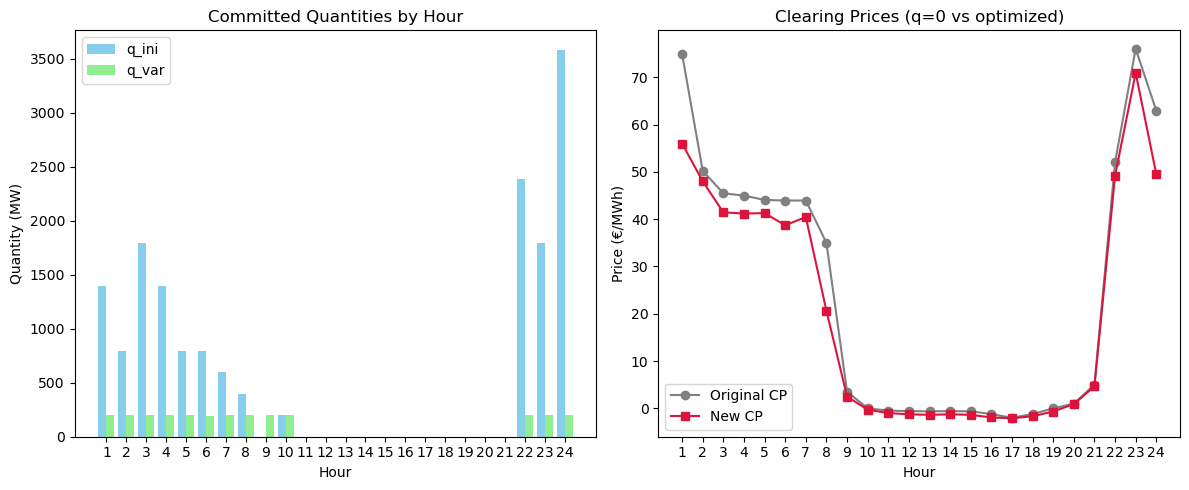

In [13]:
# --- 1) 최적화 완료 직후, 결과 추출 ---
hours      = T  # 1~24
q_ini_res  = []
q_var_res  = []
orig_price = []
new_price  = []
date_str = '20250720'  # 예시 날짜
for t in hours:
    # 선택된 block b 찾아서
    for b in valid_blocks[t]:
        if u[t,b].X > 0.5:
            q_ini_res.append(qini20[(t,b)])     # DA commit initial
            q_var_res.append(qvar[t,b].X)       # DA commit 추가량
            orig_price.append(orig_cp[(date_str, t)])  # q=0 clearing price
            new_price.append(lam20[(t,b)])      # 최적화된 DA price
            break

# --- 2) 시각화 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# 2-1) Committed Quantities by Hour
x = np.array(hours)
ax1.bar(x-0.2, q_ini_res, width=0.4, label='q_ini', color='skyblue')
ax1.bar(x+0.2, q_var_res, width=0.4, label='q_var', color='lightgreen')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Quantity (MW)')
ax1.set_title('Committed Quantities by Hour')
ax1.set_xticks(hours)
ax1.legend()

# 2-2) Clearing Prices 비교
ax2.plot(x, orig_price,    '-o', color='gray',   label='Original CP')
ax2.plot(x, new_price,     '-s', color='crimson', label='New CP')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Price (€/MWh)')
ax2.set_title('Clearing Prices (q=0 vs optimized)')
ax2.set_xticks(hours)
ax2.legend()

plt.tight_layout()
plt.show()


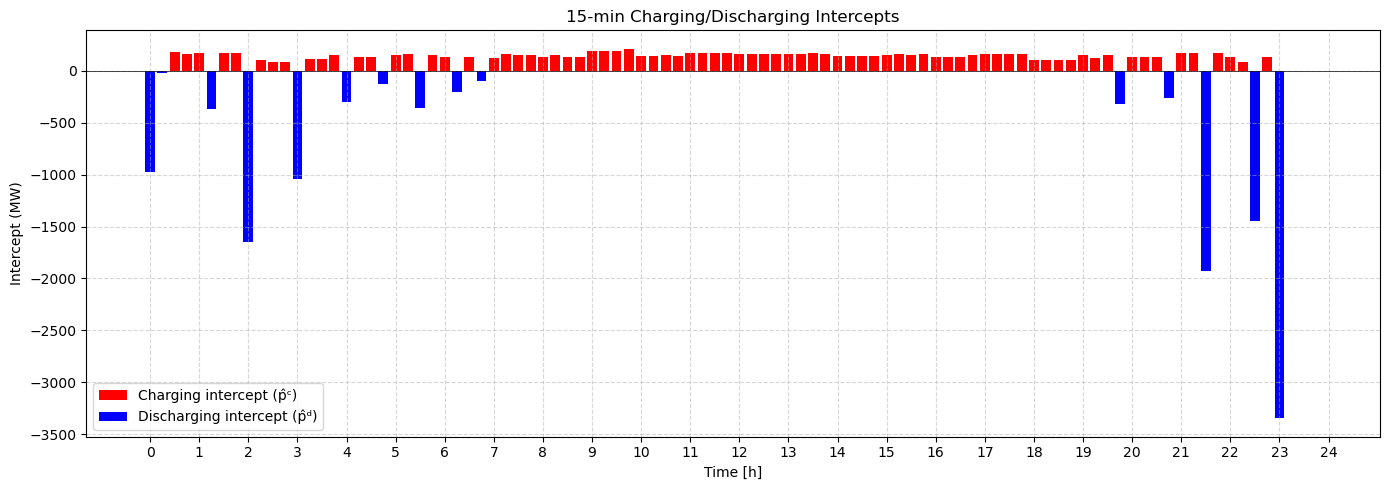

In [14]:
# T, J, p_hat_c, p_hat_d는 이미 메모리에 존재합니다
time_points  = [(t-1) + 0.25*(j-1) for t in T for j in J]
p_hat_c_flat = [p_hat_c[t,j].X for t in T for j in J]
p_hat_d_flat = [p_hat_d[t,j].X for t in T for j in J]

plt.figure(figsize=(14,5))
plt.bar(time_points, p_hat_c_flat, width=0.2, color='red',   label='Charging intercept (p̂ᶜ)')
plt.bar(time_points, [-v for v in p_hat_d_flat], width=0.2, color='blue', label='Discharging intercept (p̂ᵈ)')
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('Time [h]'); plt.ylabel('Intercept (MW)')
plt.title('15-min Charging/Discharging Intercepts')
plt.xticks(np.arange(0,24.1,1)); plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(); plt.tight_layout()
plt.show()

In [15]:
# # ─────────────────────────────────────────────────────────────
# # 1) 시간당 평균 풍력 발전량 계산
# # ─────────────────────────────────────────────────────────────
# # rho[s] 는 시나리오 확률, I = [0] 이므로 아래는 간단히 시나리오 평균만
# pwf_bar = []
# for t in T:
#     # 시나리오별 풍력량을 확률로 가중합
#     mean_wind = sum(rho[s]*pwf[(0,t,s)] for s in S)
#     pwf_bar.append(mean_wind)

# # ─────────────────────────────────────────────────────────────
# # 2) DA 오퍼량 q_DA[t] 계산 (이미 구하셨다면 이 부분은 생략하셔도 됩니다)
# # ─────────────────────────────────────────────────────────────
# q_DA = []
# for t in T:
#     qt = sum(u[t,b].X * qini20[(t,b)] + qvar[t,b].X for b in range(B))
#     q_DA.append(qt)

# # ─────────────────────────────────────────────────────────────
# # 3) 시각화: 풍력 vs. DA 오퍼량
# # ─────────────────────────────────────────────────────────────
# hours = np.array(T)
# labels = [f"{h:02d}:00" for h in T]

# fig, ax1 = plt.subplots(figsize=(12,4))
# ax2 = ax1.twinx()

# # 풍력(바)
# ax1.bar(hours-0.2, pwf_bar, width=0.4, color='tab:cyan', alpha=0.7, label='Avg Wind Farm Output')
# # DA 오퍼량(선)
# ax2.plot(hours+0.2, q_DA, 'o-', color='tab:green', lw=2, label='DA Offer Quantity')

# # 축 레이블 & 타이틀
# ax1.set_xlabel("Hour of Day")
# ax1.set_ylabel("Wind Output (MW)", color='tab:cyan')
# ax2.set_ylabel("DA Offer (MW)",   color='tab:green')
# ax1.set_xticks(hours)
# ax1.set_xticklabels(labels, rotation=45)
# ax1.set_title("Hourly Wind Farm Output vs. DA Offer Quantity")

# # 범례 합치기
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')

# ax1.grid(axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()


### Model 2

In [91]:
# 1) 날짜 및 시나리오 정의
date_range = [f"202507{d:02d}" for d in range(20, 28)]  # 20,21,…,27
S = list(range(len(date_range)))                      # 시나리오 0~7
T = list(range(1, 25))                                # 시간 1~24
I = list(range(1))                                     # 풍력 설비 0번만
J = [1,2,3,4]                      # 15분 분할
Δt = 0.25

# 시나리오 확률 (균등)
rho = {s: 1/len(S) for s in S}

# 2) ESS 파라미터
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500

In [92]:
# 2) RDC 시나리오 파라미터 맵 생성
qini_scen       = {}
qmax_scen       = {}
lambda_da_scen  = {}

for s, date in enumerate(date_range):
    # qini
    for (d,t,b), q in qini.items():
        if d == date:
            qini_scen[(s,t,b)] = q
    # qmax
    for (d,t,b), Δ in qmax.items():
        if d == date:
            qmax_scen[(s,t,b)] = Δ
    # lambda_da
    for (d,t,b), π in lambda_da_block.items():
        if d == date:
            lambda_da_scen[(s,t,b)] = π

# ─────────────────────────────────────────────────────────────
# 3) valid_blocks 재생성: qmax_scen 에서 t별로 Δ>0 인 b만 남김
valid_blocks = {
    t: sorted({ b
                for (s2,t2,b),Δ in qmax_scen.items()
                if t2==t and Δ>0 })
    for t in T
}

In [93]:
# 기존에 (s, t, b) 순서로 되어 있던 시나리오 맵을 (t, b, s) 순서로 뒤집어 재생성
qini_scen      = { (t,b,s): qini_scen[(s,t,b)]       for (s,t,b)   in qini_scen      }
qmax_scen      = { (t,b,s): qmax_scen[(s,t,b)]       for (s,t,b)   in qmax_scen      }
lambda_da_scen = { (t,b,s): lambda_da_scen[(s,t,b)]  for (s,t,b)   in lambda_da_scen }

# 예시로 확인해보기 (pandas로 표 형태로)
import pandas as pd

df = pd.DataFrame([
    {"t":t, "b":b, "s":s,
     "qini": q, 
     "qmax": qmax_scen[(t,b,s)],
     "lam_da": lambda_da_scen[(t,b,s)]}
    for (t,b,s), q in qini_scen.items()
])
display(df.sort_values(["t","b","s"]).head(10))


,t,b,s,qini,qmax,lam_da
0,1,0,0,0.0,50.0,71.765548
11438,1,0,1,0.0,50.0,74.843114
25432,1,0,2,0.0,200.0,111.937961
41906,1,0,3,0.0,200.0,104.107187
58228,1,0,4,0.0,200.0,90.301598
69084,1,0,5,0.0,50.0,59.980242
80593,1,0,6,0.0,10.0,79.009471
95114,1,0,7,0.0,10.0,67.451865
1,1,1,0,50.0,50.0,71.534145
11439,1,1,1,50.0,50.0,74.758256


In [94]:
#deterministic rt price and wf generation
#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
rt_price_15min = 0.5 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
rt15_arr = np.array(rt_price_15min).reshape(24, 4)

# (t,j) → price 사전 생성
#  t=1..24,  j=1..4
lambda_rt = {
    (t, j): float(rt15_arr[t-1, j-1])
    for t in T for j in J
}

# 풍력 발전량 시나리오 pwf[i,t,s]
np.random.seed(0)
Cw = 1000
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*0.85, Cw*0.20))
    for i in I for t in T for s in S
}
# 풍력 예측 & RT 가격 (Deterministic)
pwf_forecast = {
    (i, t): np.mean([ pwf[(i, t, s)] for s in S ])
    for i in I for t in T
}



In [95]:
# ─── 2) 모델 생성 ──────────────────────────────────────────
model = gp.Model("RDC_Scenarios_Single_ESS")

# 2.1) RDC 시나리오 변수
u      = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    vtype=GRB.BINARY, name="u"
)
# “추가 수량”은 시나리오별 recourse 결정변수로 변경
qvar   = model.addVars(
    [(t,b,s) for t in T for b in valid_blocks[t] for s in S],
    lb=0.0, name="qvar"
)
p_bid   = model.addVars([(t,s) for t in T for s in S],
                        lb=0.0, name="p_bid")

p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# 2.2) ESS here-and-now 변수
u_c = model.addVars([(t,j) for t in T for j in J],
                    vtype=GRB.BINARY, name="u_c")
u_d = model.addVars([(t,j) for t in T for j in J],
                    vtype=GRB.BINARY, name="u_d")


p_c = model.addVars([(t,j) for t in T for j in J],
                    lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j) for t in T for j in J],
                    lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j) for t in T for j in J],
                    lb=E_min, ub=E_max, name="E_q")
p_b   = model.addVars( [(t,j) for t in T for j in J] ,lb=0.0, name="p_b")

#  2) 목적함수
da_rev = gp.quicksum(
    rho[s]
  * lambda_da_scen[(t,b,s)]
  * (u[t,b]*qini_scen[(t,b,s)] + qvar[t,b,s])
  for s in S for t in T for b in valid_blocks[t]
)

rt_rev = gp.quicksum(
    rho[s]
  * lambda_rt[(t, j)]   # 15분 구간별 price                     # 0.25h
  * (p_b[t,j]              # 시간 t, 시나리오 s 의 실제 잔량
      - (p_bid[t,s]/4)   # 시간 t 의 DA 약속량을 4등분
    )
  for s in S
    for t in T
    for j in J
)

# rt_rev = gp.quicksum(
#     rho[s]
#   * lambda_rt[(t,j)] * Δt
#   * (p_b[t] - p_bid[t,s]
#     )
#   for s in S for t in T
# )
model.setObjective(da_rev + rt_rev, GRB.MAXIMIZE)

# ─── 4) 제약식 ───────────────────────────────────────────────
# 3.1) 블록 선택 (Here-and-Now)
for t in T:
    model.addConstr(
        gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
        name=f"one_block_{t}"
    )

# 3.2) qvar ≤ qmax * u  (Recourse)
for t in T:
    for b in valid_blocks[t]:
        for s in S:
            model.addConstr(
                qvar[t,b,s] <= qmax_scen[(t,b,s)] * u[t,b],
                name=f"qvar_max_{t}_{b}_{s}"
            )

# 3.3) p_bid 정의
for t in T:
    for s in S:
        model.addConstr(
            p_bid[t,s] == gp.quicksum(
                u[t,b]*qini_scen[(t,b,s)]
              + qvar[t,b,s]
                for b in valid_blocks[t]
            ), name=f"p_bid_def_{t}_{s}"
        )


# 4.3) RDC: p_b 정의 (1b)
for t in T:
    for j in J:
        model.addConstr(
            p_b[t,j]
            == (sum(pwf_forecast[(i,t)] for i in I)/4)
            + p_d[t,j]
            - p_c[t,j],
            name=f"p_b_def_{t}_{j}"
        )

# 4.4) DA vs RT 약속량 한계 (1g)
for t in T:
    for s in S:
        model.addConstr(
            -gp.quicksum(p_c[t,j] for j in J) <= p_bid[t,s],
            name=f"bid_low_{t}_{s}"
        )
        for i in I:
            model.addConstr(
                p_bid[t,s] <= pwf_forecast[i,t]
                            + gp.quicksum(p_d[t,j] for j in J),
                name=f"bid_up_{t}_{s}"
            )

# 4.5) ESS: 충·방전 동시 금지 & big-M (1k)
for t in T:
    for j in J:
        model.addConstr(u_c[t,j] + u_d[t,j] <= 1,
                        name=f"no_sim_{t}_{j}")
        model.addConstr(p_c[t,j] <= pc_max * u_c[t,j],
                        name=f"pc_bigm_{t}_{j}")
        model.addConstr(p_d[t,j] <= pd_max * u_d[t,j],
                        name=f"pd_bigm_{t}_{j}")

# 4.6) ESS: SOC 동적 전이 (1j)
for t in T:
    for j in J:
        prev = E0 if (t==1 and j==1) else (
            E_q[t-1,4] if j==1 else E_q[t,j-1]
        )
        model.addConstr(
            E_q[t,j] == prev
                       + Δt*(eta_c*p_c[t,j] - p_d[t,j]/eta_d),
            name=f"SOC_{t}_{j}"
        )

# 4.7) SOC 경계 (1n) 은 이미 변수에 적용됨

# ─── 5) 최적화 ───────────────────────────────────────────────
model.Params.TimeLimit = 60
model.optimize()

KeyError: (1, 709, 0)

Profit for s: [ 889006.59997779 1964544.01363982 2840656.1221719  2551681.32589866
 1080099.12240054 1092807.66243741 1190298.4545861  1017123.95321402]
obj func 1578277.1567907806
model obj 1589841.4902389066


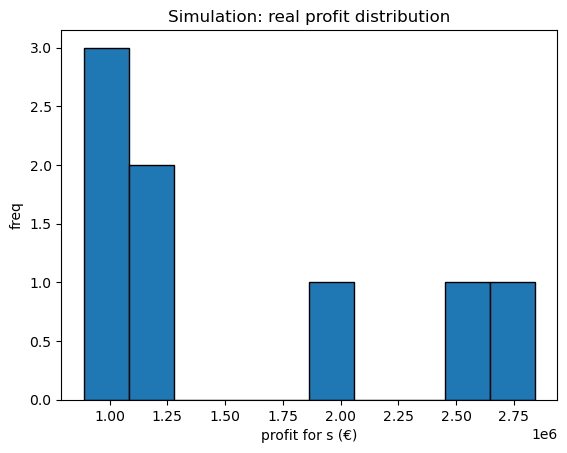

In [75]:
# 1) 각 시나리오별 profit 계산
profits = []  # s별 합수익
for s in S:
    da_rev_s = 0.0
    rt_rev_s = 0.0

    # DA 수익
    for t in T:
        for b in valid_blocks[t]:
            da_rev_s += lambda_da_scen[(t,b,s)] \
                        * (u[t,b].X * qini_scen[(t,b,s)] + qvar[t,b,s].X)

    # RT 수익 (15분 구간)
    for t in T:
        for j in J:
            # p_bid_s_t = sum(...) 대신 p_bid[t,s].X 이용 가능
            p_bid_s_t = p_bid[t,s].X  
            p_b_s_tj = (
                sum(pwf[(i,t,s)] for i in I) / 4.0
                + p_d[t,j].X
                - p_c[t,j].X
            )
            price_rt = lambda_rt[(t,j)]
            rt_rev_s += price_rt * Δt * (p_b_s_tj - p_bid_s_t/4.0)

    profits.append(da_rev_s + rt_rev_s)

# 2) 결과 요약
profits = np.array(profits)
print("Profit for s:", profits)
print("obj func", np.dot(profits, [rho[s] for s in S]))
print("model obj", model.ObjVal)

# 3) 히스토그램
import matplotlib.pyplot as plt
plt.hist(profits, bins=10, edgecolor='k')
plt.xlabel("profit for s (€)")
plt.ylabel("freq")
plt.title("Simulation: real profit distribution")
plt.show()

In [ ]:
import math


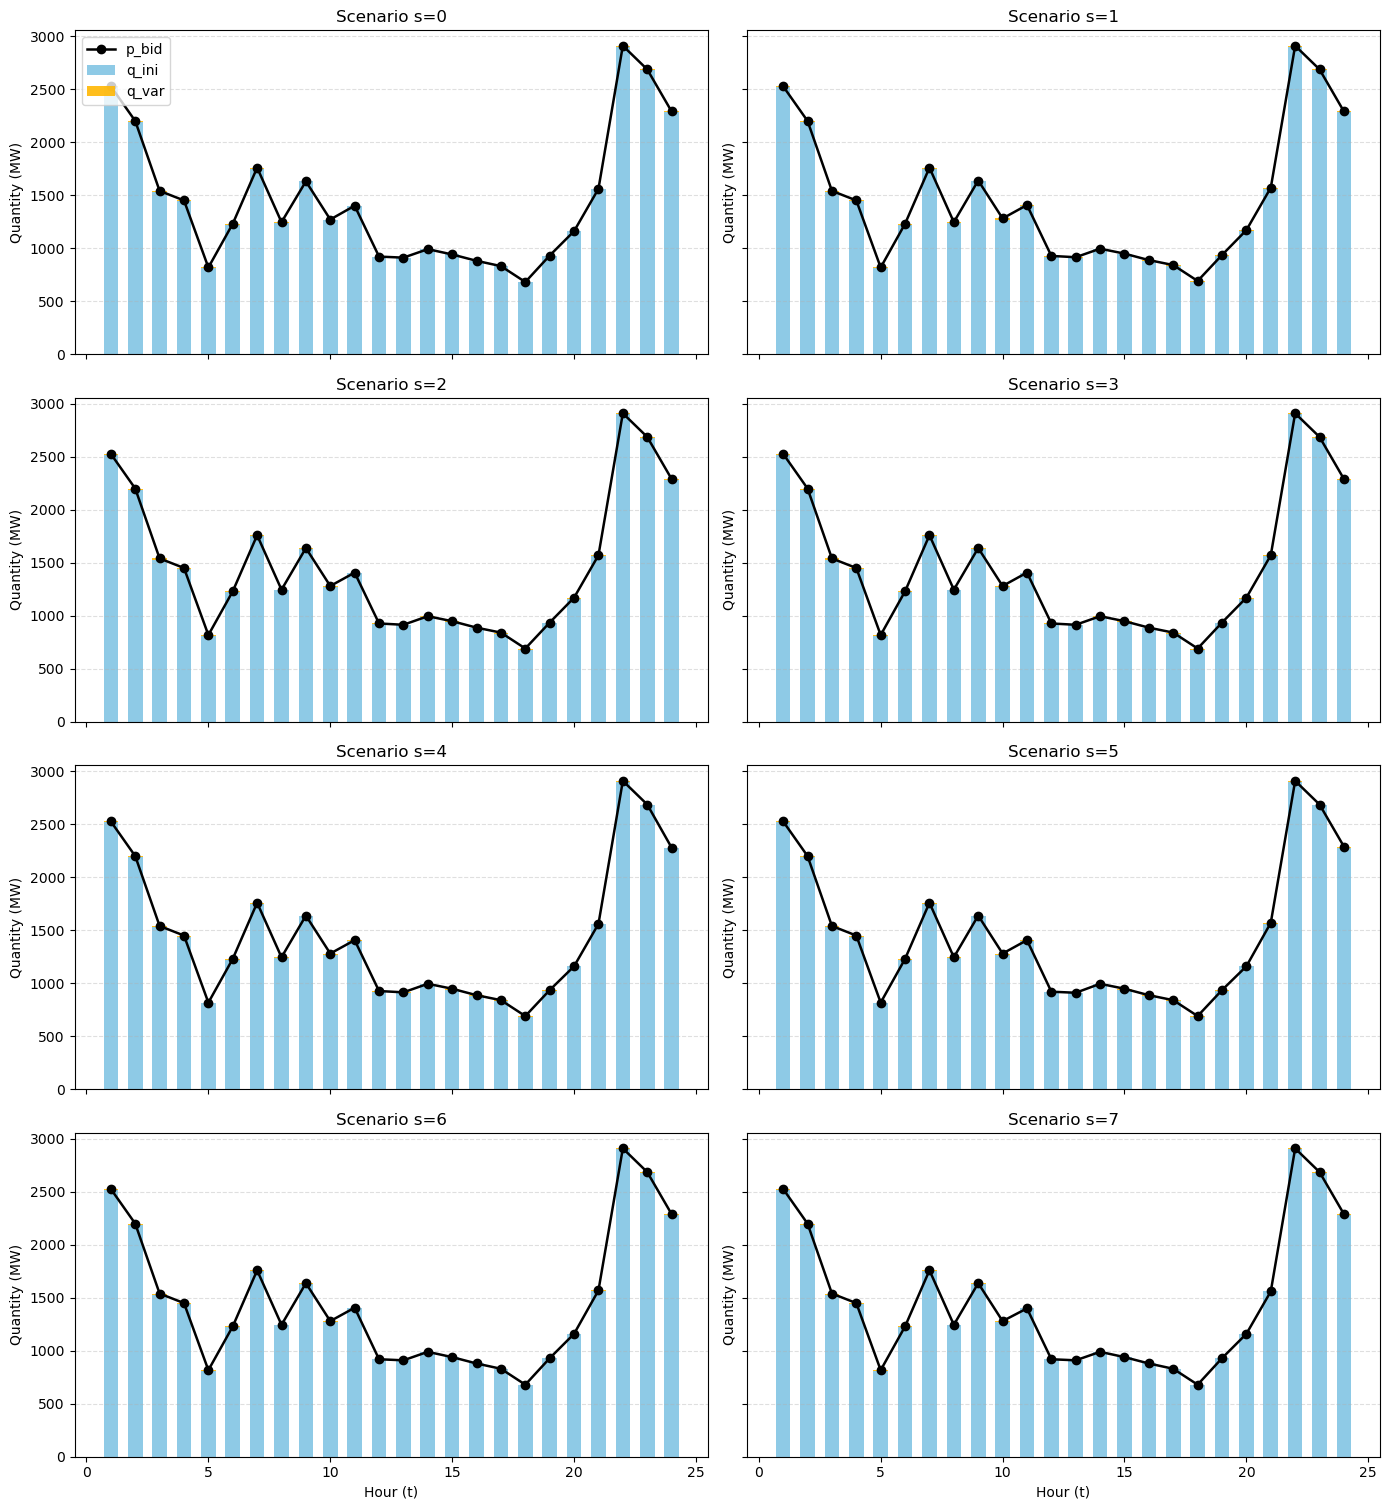

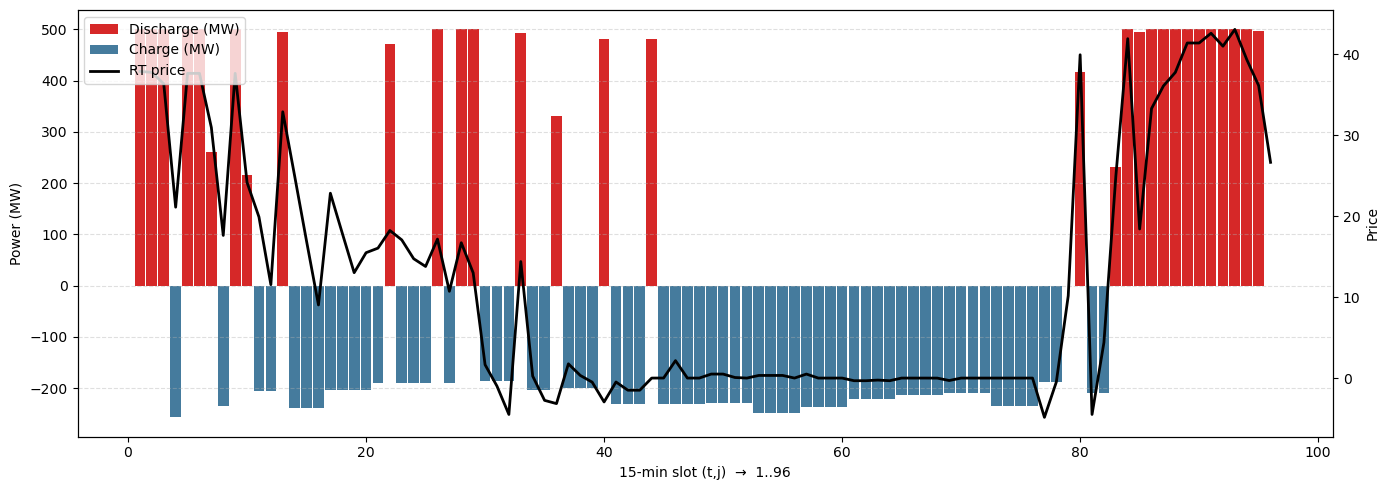

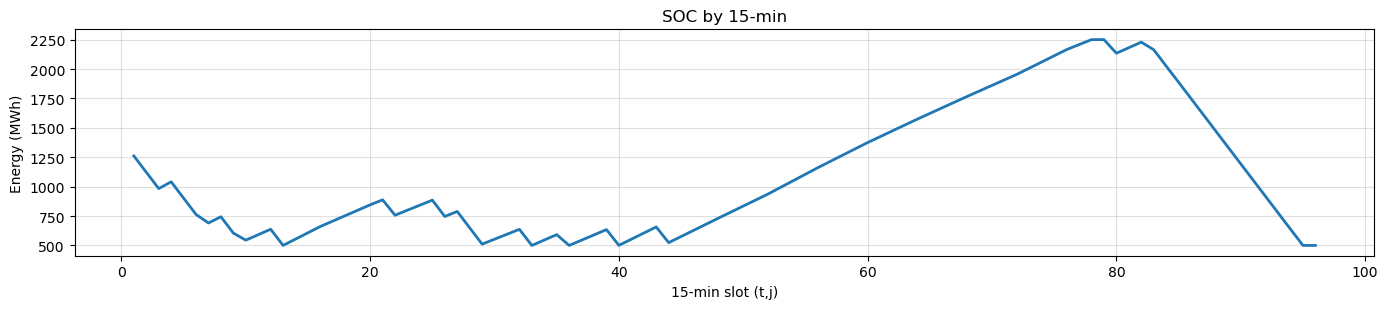

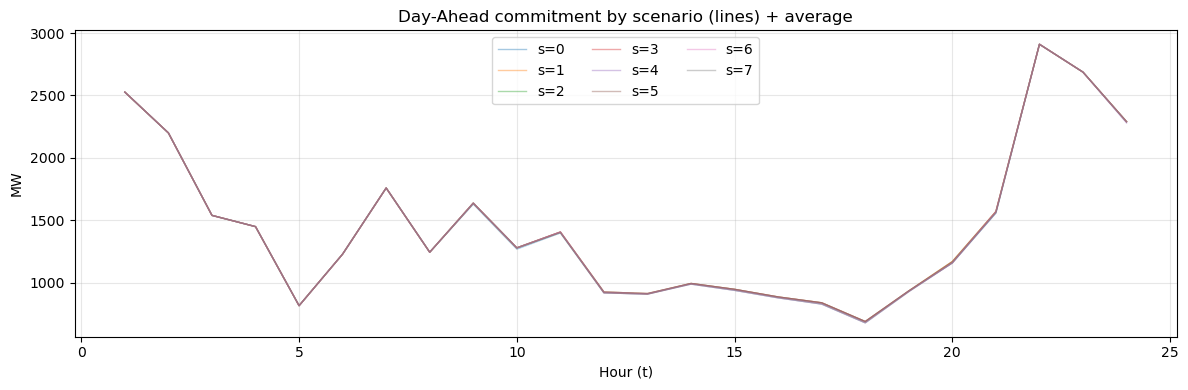

In [76]:


hours = list(T)
S_list = list(S)

def get_qini_by_ts(s, t):
    """시나리오 s, 시간 t의 블록 기본 약속량 합계 = sum_b u[t,b]*qini_scen[(t,b,s)]"""
    return sum(u[t,b].X * qini_scen[(t,b,s)] for b in valid_blocks[t])

def get_qvar_by_ts(s, t):
    """시나리오 s, 시간 t의 블록 추가 약속량 합계 = sum_b qvar[t,b,s]"""
    return sum(qvar[t,b,s].X for b in valid_blocks[t])

# 각 시나리오별 데이터 구성
qini_ts   = {s: [get_qini_by_ts(s,t) for t in hours] for s in S_list}
qvar_ts   = {s: [get_qvar_by_ts(s,t) for t in hours] for s in S_list}
pbid_ts   = {s: [p_bid[t,s].X for t in hours]        for s in S_list}

# 서브플롯(시나리오별) – 2열 그리드
nS = len(S_list)
ncols = 2
nrows = math.ceil(nS / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.8*nrows), sharex=True, sharey=True)

if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = np.array([axes])

for idx, s in enumerate(S_list):
    r = idx // ncols
    c = idx %  ncols
    ax = axes[r, c]

    base = np.array(qini_ts[s])
    add  = np.array(qvar_ts[s])
    ax.bar(hours, base, width=0.6, label='q_ini', color='#8ecae6')
    ax.bar(hours, add,  bottom=base, width=0.6, label='q_var', color='#ffb703', alpha=0.9)
    ax.plot(hours, pbid_ts[s], '-o', lw=1.8, color='k', label='p_bid')

    ax.set_title(f'Scenario s={s}')
    ax.set_ylabel('Quantity (MW)')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if r == nrows-1:
        ax.set_xlabel('Hour (t)')
    if r == 0 and c == 0:
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) 15분 ESS 충방전 + RT 가격
#    - 막대: 충전은 음수(파랑), 방전은 양수(빨강)로 표시
#    - 선  : 15분 RT 가격 lambda_rt[(t,j)]
# ------------------------------------------------------------
quarters = list(J)
slot_x = []
bar_val = []    # 방전(+), 충전(-)
rt_line = []
soc_line = []

for t in hours:
    for j in quarters:
        slot_x.append((t-1)*len(quarters) + j)    # 1..96
        # 충/방전 (Here-and-Now): 방전 양수, 충전 음수로 표시
        dis = p_d[t,j].X
        cha = p_c[t,j].X
        bar_val.append(dis - cha)
        # RT 가격(주어진 dict/array 가정)
        rt_line.append(lambda_rt[(t,j)])
        # SOC (있으면)
        soc_line.append(E_q[t,j].X)

fig, ax = plt.subplots(figsize=(14,5))
# 충전(음수, 파랑), 방전(양수, 빨강)
ax.bar(slot_x, [max(v,0) for v in bar_val], width=0.9, label='Discharge (MW)', color='#d62828')
ax.bar(slot_x, [min(v,0) for v in bar_val], width=0.9, label='Charge (MW)',    color='#457b9d')

ax.set_xlabel('15-min slot (t,j)  →  1..96')
ax.set_ylabel('Power (MW)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 오른쪽축: RT 가격
ax2 = ax.twinx()
ax2.plot(slot_x, rt_line, lw=2.0, label='RT price', color='k')
ax2.set_ylabel('Price')

# 범례 깔끔하게 합치기
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, loc='upper left')

plt.tight_layout()
plt.show()

# (선택) SOC 시계열
plt.figure(figsize=(14,3.2))
plt.plot(slot_x, soc_line, lw=2)
plt.title('SOC by 15-min')
plt.xlabel('15-min slot (t,j)')
plt.ylabel('Energy (MWh)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) 보너스: 시나리오 평균 커밋먼트 vs 개별 시나리오 라인
# ------------------------------------------------------------
plt.figure(figsize=(12,4))
for s in S_list:
    plt.plot(hours, pbid_ts[s], alpha=0.4, lw=1, label=f's={s}')
avg_pbid = np.mean([pbid_ts[s] for s in S_list], axis=0)
# plt.plot(hours, avg_pbid, color='k', lw=2.5, label='avg p_bid')
plt.title('Day-Ahead commitment by scenario (lines) + average')
plt.xlabel('Hour (t)'); plt.ylabel('MW'); plt.grid(True, alpha=0.3); plt.legend(ncol=3)
plt.tight_layout()
plt.show()
